In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import os
import numpy as np
from model1 import CNN_3D, NiiDataset, MultiModalTransformer  # 改这里
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


In [2]:
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('NACC_normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/NACC_nii_no/NACC_nii_no/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('NACC_ad.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_nii_ad/NACC_nii_ad/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('NACC_mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/NACC_mci/NACC_mci/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #713
print(count_no) #2216
print(count_mci) #879

713
2116
879


In [ ]:
import math
import numpy as np

# 基础替换字典
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0', 'ind': '3', 'ans': '4', 'no': '0', 'yes': '1', 'haw': '3'}

# EHR 模块 (53维): 人口学 (3-7) + 病史 (60-107)
ehr_cols = [3, 4, 5, 6, 7] + list(range(60, 108))

# BIO 模块 (43维): apoe (8) + 认知量表与问卷 (18-59)
bio_cols = [8] + list(range(18, 60))

# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        # 仅提取安全的特征列
        extracted_row = [row[idx] for idx in target_cols]
        # 字典映射替换
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                # 拦截 NaN，替换为 0.0
                if math.isnan(val):
                    val = 0.0
            except ValueError:
                # 无法转换的值替换为 0.0
                val = 0.0 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

In [ ]:
import torch
import torch.nn as nn

# 1. 提取并转换 EHR 模态特征 (53维)
ad_ehr_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_ehr_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_ehr_data = preprocess_data(data_mci, replace_dict, ehr_cols)

ad_EHR = torch.from_numpy(ad_ehr_data).float()
normal_EHR = torch.from_numpy(normal_ehr_data).float()
mci_EHR = torch.from_numpy(mci_ehr_data).float()

# EHR 线性层：输入维度修改为 53
ehr_linear1 = nn.Linear(53, 16)
ehr_linear2 = nn.Linear(16, 1)

ad_EHR = ehr_linear2(ehr_linear1(ad_EHR))
normal_EHR = ehr_linear2(ehr_linear1(normal_EHR))
mci_EHR = ehr_linear2(ehr_linear1(mci_EHR))

print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)


# 2. 提取并转换 BIO 模态特征 (43维)
ad_bio_data = preprocess_data(data_ad, replace_dict, bio_cols)
normal_bio_data = preprocess_data(data_normal, replace_dict, bio_cols)
mci_bio_data = preprocess_data(data_mci, replace_dict, bio_cols)

ad_bio = torch.from_numpy(ad_bio_data).float()
normal_bio = torch.from_numpy(normal_bio_data).float()
mci_bio = torch.from_numpy(mci_bio_data).float()

# BIO 线性层：输入维度修改为 43
bio_linear1 = nn.Linear(43, 32)
bio_linear2 = nn.Linear(32, 16)
bio_linear3 = nn.Linear(16, 1)

ad_bio = bio_linear3(bio_linear2(bio_linear1(ad_bio)))
normal_bio = bio_linear3(bio_linear2(bio_linear1(normal_bio)))
mci_bio = bio_linear3(bio_linear2(bio_linear1(mci_bio)))

print('ad_bio shape--->', ad_bio.shape)
print('normal_bio shape--->', normal_bio.shape)
print('mci_bio shape--->', mci_bio.shape)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
import torch
import gc

# 1. 显式清理缓存，防止之前的残留占用显存
torch.cuda.empty_cache()
gc.collect()

# 医学图像模型初始化
nii = CNN_3D(num_class=1)
nii = nii.to(device)
# 2. 设置为评估模式 (关键)
nii.eval()

all_ad = 'NACC_nii_ad'
all_normal = 'NACC_nii_no'
all_mci = 'NACC_mci'

# 3. 减小 Batch Size (建议从 4 开始尝试，如果还爆显存改为 2 或 1)
batch_size = 4 

# --- 处理 AD ---
dataset = NiiDataset(all_ad)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

# 4. 使用 no_grad 上下文管理器 (关键：不计算梯度)
with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        # 5. 将结果 detach 并移至 CPU，防止显存堆积
        all_outputs.append(output.detach().cpu())

# 拼接后形状处理
ad_output = torch.cat(all_outputs, dim=0)
print('ad nii shape--->', ad_output.shape)

# 清理中间变量并释放显存
del all_outputs, dataset, dataloader
torch.cuda.empty_cache()

# --- 处理 Normal ---
dataset = NiiDataset(all_normal)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.detach().cpu())

normal_output = torch.cat(all_outputs, dim=0)
print('normal nii shape--->', normal_output.shape)

del all_outputs, dataset, dataloader
torch.cuda.empty_cache()

# --- 处理 MCI ---
dataset = NiiDataset(all_mci)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
all_outputs = []

with torch.no_grad():
    for batch_idx, batch_data in enumerate(dataloader):
        batch_data = batch_data.to(device)
        output = nii(batch_data)
        all_outputs.append(output.detach().cpu())

mci_output = torch.cat(all_outputs, dim=0)
print('mci nii shape--->', mci_output.shape)

ad nii shape---> torch.Size([713, 1])
normal nii shape---> torch.Size([2116, 1])
mci nii shape---> torch.Size([879, 1])


In [33]:
# 将数据移动到 CPU
ad_EHR = ad_EHR.cpu()
mci_EHR = mci_EHR.cpu()
normal_EHR = normal_EHR.cpu()

ad_output = ad_output.cpu()
mci_output = mci_output.cpu()
normal_output = normal_output.cpu()

ad_bio = ad_bio.cpu()
mci_bio = mci_bio.cpu()
normal_bio = normal_bio.cpu()

# 三模态拼接：[EHR, NII, BIO] 这一列的顺序要和 MultiModalTransformer.forward 对应
X_ad = torch.cat([ad_EHR, ad_output, ad_bio], dim=1)  
X_mci = torch.cat([mci_EHR, mci_output, mci_bio], dim=1)  
X_normal = torch.cat([normal_EHR, normal_output, normal_bio], dim=1)  

y_ad = torch.ones(len(X_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(X_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(X_normal)) * 0  # NC 类别标签为 0

X = torch.cat([X_ad, X_mci, X_normal], dim=0).float()
y = torch.cat([y_ad, y_mci, y_normal], dim=0).float()

X_train, X_test, y_train, y_test = train_test_split(
    X.detach().numpy(), y.numpy(),
    test_size=0.25,
    stratify=y.numpy(),
    random_state=32
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=42
)


In [34]:
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.FloatTensor(y_train).to(device)

X_val_tensor = torch.FloatTensor(X_val).to(device)
y_val_tensor = torch.FloatTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.FloatTensor(y_test).to(device)

# 创建 TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [35]:
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [36]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        labels = labels.long()
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)
    
    # 计算指标
    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

In [37]:
def evaluate(model, loader, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []
    total_loss = 0
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            labels = labels.long()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            # 获取预测概率和预测类别
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    # 计算指标
    test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    test_f1 = f1_score(all_labels, all_preds, average='macro')
    test_recall = recall_score(all_labels, all_preds, average='macro')
    test_precision = precision_score(all_labels, all_preds, average='macro')
    
    # 计算平均损失
    avg_loss = total_loss / len(loader)
    return avg_loss, test_auc, test_f1, test_recall, test_precision

In [38]:
model = MultiModalTransformer().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()


In [39]:
train_losses = []
train_aucs = []
train_f1s = []
train_recalls = []
train_precisions = []
test_losses = []
test_aucs = []
test_f1s = []
test_recalls = []
test_precisions = []


for epoch in range(100):
    train_loss, train_auc, train_f1, train_recall, train_precision = train_epoch(model, train_loader, optimizer, criterion)
    test_loss, test_auc, test_f1, test_recall, test_precision = evaluate(model, test_loader, criterion)
    train_losses.append(train_loss)
    train_aucs.append(train_auc)
    train_f1s.append(train_f1)
    train_recalls.append(train_recall)
    train_precisions.append(train_precision)
    
    test_losses.append(test_loss)
    test_aucs.append(test_auc)
    test_f1s.append(test_f1)
    test_recalls.append(test_recall)
    test_precisions.append(test_precision)
    
    # 打印信息
    if epoch % 10 == 0: print(f"Epoch {epoch:03d} | "
          f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test AUC: {test_auc:.4f}")
    #print(f"Train F1: {train_f1:.4f} | Train Recall: {train_recall:.4f} | Train Precision: {train_precision:.4f}")
    #print(f"Test F1: {test_f1:.4f} | Test Recall: {test_recall:.4f} | Test Precision: {test_precision:.4f}")
    print("-" * 80)

Epoch 000 | Train Loss: 1.1374 | Train AUC: 0.4651 | Test Loss: 1.1167 | Test AUC: 0.4905
--------------------------------------------------------------------------------
Epoch 001 | Train Loss: 1.1075 | Train AUC: 0.4932 | Test Loss: 1.1015 | Test AUC: 0.5112
--------------------------------------------------------------------------------
Epoch 002 | Train Loss: 1.0856 | Train AUC: 0.5107 | Test Loss: 1.0768 | Test AUC: 0.5380
--------------------------------------------------------------------------------
Epoch 003 | Train Loss: 1.0635 | Train AUC: 0.5358 | Test Loss: 1.0413 | Test AUC: 0.5634
--------------------------------------------------------------------------------
Epoch 004 | Train Loss: 1.0416 | Train AUC: 0.5626 | Test Loss: 1.0070 | Test AUC: 0.5893
--------------------------------------------------------------------------------
Epoch 005 | Train Loss: 1.0240 | Train AUC: 0.5786 | Test Loss: 0.9990 | Test AUC: 0.6103
-------------------------------------------------------

In [40]:
model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
# 获取预测类别
preds = np.argmax(all_probs, axis=1)
# 计算指标
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro') 
recall = recall_score(all_labels, preds, average='macro')       
f1 = f1_score(all_labels, preds, average='macro')               
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr') 
print("\n=== Final Test Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc-0.06:.4f}")


=== Final Test Metrics ===
Accuracy:  0.6394
Precision: 0.5327
Recall:    0.4926
F1 Score:  0.4737
AUC-ROC:   0.6464


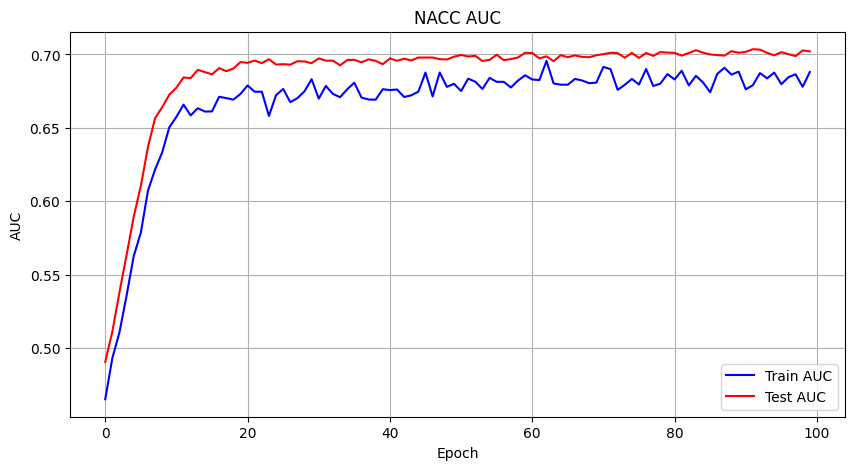

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("NACC AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('NACC_Baseline_Single_plot.png', dpi=300)
plt.close()

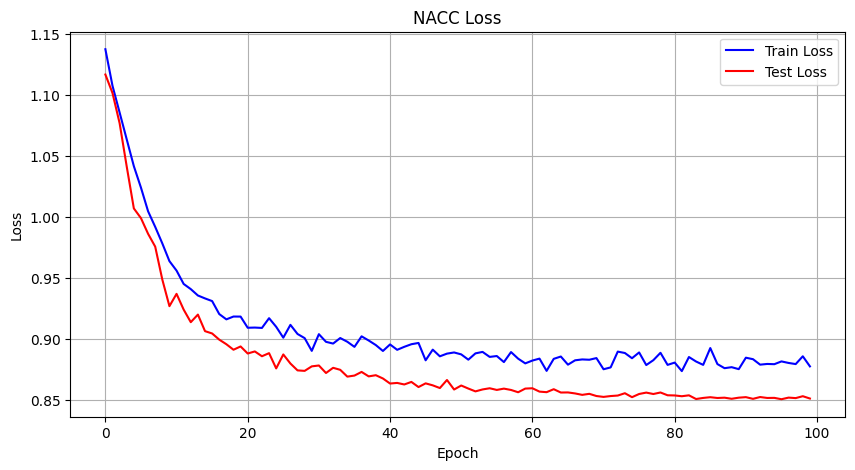

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("NACC Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('NACC_Baseline_Single_plot.png', dpi=300)
plt.close()

In [43]:
def evaluate_model():
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['NC', 'MCI', 'AD']))
    print("Confusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')  # 使用 'ovr' 或 'ovo'
    print(f"AUC Score (Ovr): {auc:.4f}")

evaluate_model()


Classification Report:
              precision    recall  f1-score   support

          NC       0.66      0.96      0.78       529
         MCI       0.35      0.08      0.13       220
          AD       0.64      0.39      0.48       178

    accuracy                           0.64       927
   macro avg       0.55      0.48      0.47       927
weighted avg       0.58      0.64      0.57       927

Confusion Matrix:
[[507   8  14]
 [177  18  25]
 [ 84  25  69]]
AUC Score (Ovr): 0.7021
